In [26]:
# !pip install -U diffusers transformers peft datasets pillow

In [27]:
# import torch
# from diffusers import AutoPipelineForImage2Image
# from diffusers.utils import load_image

# model_id = "runwayml/stable-diffusion-v1-5"

# pipe = AutoPipelineForImage2Image.from_pretrained(
#     model_id,
#     torch_dtype=torch.float16,
#     safety_checker=None
# ).to(device)

# init_image = load_image("img.jpeg").convert("RGB").resize((512, 512))

# prompt = "A portrait in watercolor painting style, soft brush strokes, artistic"
# image = pipe(
#     prompt=prompt,
#     image=init_image,
#     strength=0.6,
#     guidance_scale=7.5
# ).images[0]

# image.save("baseline_output.png")


# Van gogh style

In [1]:
import os
from datasets import load_dataset
from PIL import Image

# Settings
dataset_name = "ameliasasinDDG/vanGogh"
num_samples = 30
image_dir = "/content/vangogh_data/images"
caption_dir = "/content/vangogh_data/caption"
caption_text = "vgoghstyle painting"
target_size = 512

os.makedirs(image_dir, exist_ok=True)
os.makedirs(caption_dir, exist_ok=True)

def resize_and_center_crop(img, size=512):
    img = img.convert("RGB")
    w, h = img.size

    scale = size / min(w, h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    img = img.resize((new_w, new_h), Image.LANCZOS)

    left = (new_w - size) // 2
    top = (new_h - size) // 2
    right = left + size
    bottom = top + size

    return img.crop((left, top, right, bottom))

# Load dataset
ds = load_dataset(dataset_name, split="train")

# Take first 30 samples - will increase in case the model is not performing well
subset = ds.select(range(min(num_samples, len(ds))))

for idx, sample in enumerate(subset, start=1):
    img = sample["source"]

    img = resize_and_center_crop(img, size=target_size)

    base_name = f"img{idx:03d}"

    img.save(os.path.join(image_dir, f"{base_name}.jpg"), quality=95)

    with open(os.path.join(caption_dir, f"{base_name}.txt"), "w", encoding="utf-8") as f:
        f.write(caption_text)

print(f"Saved {len(subset)} images to {image_dir}")
print(f"Saved {len(subset)} captions to {caption_dir}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/490 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/452M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/473M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/530 [00:00<?, ? examples/s]

Saved 30 images to /content/vangogh_data/images
Saved 30 captions to /content/vangogh_data/caption


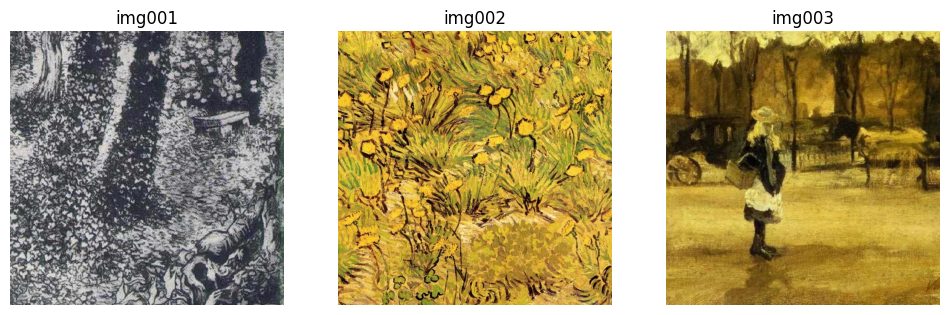

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes, start=1):
    img = Image.open(f"/content/vangogh_data/images/img{i:03d}.jpg")
    ax.imshow(img)
    ax.set_title(f"img{i:03d}")
    ax.axis("off")
plt.show()

In [3]:
import os
import math
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from peft import LoraConfig
from diffusers import StableDiffusionPipeline, DDPMScheduler
from transformers import CLIPTokenizer


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5"

image_dir = "/content/vangogh_data/images"
caption_dir = "/content/vangogh_data/caption"
output_dir = "/content/vangogh_lora_manual"
os.makedirs(output_dir, exist_ok=True)

resolution = 512
batch_size = 1
grad_accum_steps = 4
num_epochs = 7
learning_rate = 5e-5
max_grad_norm = 1.0
save_every = 200


In [5]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
vae = pipe.vae
unet = pipe.unet
noise_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [6]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.1,
    bias="none"
)

unet.add_adapter(lora_config)

for name, param in unet.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()
        print("trainable:", name, param.dtype)


trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q.lora_A.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q.lora_B.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.lora_A.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.lora_B.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v.lora_A.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v.lora_B.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.lora_A.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.lora_B.default.weight torch.float32
trainable: down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q.lora_A.default.weight torch.float32
trainable: down_blocks.0.attentions.0.

In [7]:
class VanGoghDataset(Dataset):
    def __init__(self, image_dir, caption_dir, tokenizer, size=512):
        self.image_dir = image_dir
        self.caption_dir = caption_dir
        self.tokenizer = tokenizer
        self.size = size

        self.files = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".jpeg")
        ])

        self.transform = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        image_name = self.files[idx]
        base = os.path.splitext(image_name)[0]
        caption_path = os.path.join(self.caption_dir, base + ".txt")

        image = Image.open(os.path.join(self.image_dir, image_name)).convert("RGB")
        image = self.transform(image)

        with open(caption_path, "r", encoding="utf-8") as f:
            caption = f.read().strip()

        tokens = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt"
        )

        return {
            "pixel_values": image,
            "input_ids": tokens.input_ids[0]
        }


In [8]:
dataset = VanGoghDataset(image_dir, caption_dir, tokenizer, size=resolution)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("dataset size:", len(dataset))


dataset size: 30


In [9]:
optimizer = torch.optim.AdamW(
    [p for p in unet.parameters() if p.requires_grad],
    lr=learning_rate
)


## Training

In [10]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import os

output_dir = "/content/vangogh_lora_manual"

unet.train()
global_step = 0
loss_history = []
log_steps = []
optimizer.zero_grad(set_to_none=True)
for epoch in range(num_epochs):
    running_loss = 0.0

    for step, batch in enumerate(dataloader):
        pixel_values = batch["pixel_values"].to(device, dtype=next(vae.parameters()).dtype)
        input_ids = batch["input_ids"].to(device)

        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

            noise = torch.randn_like(latents)
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],),
                device=device
            ).long()

            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = text_encoder(input_ids)[0]

        model_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_hidden_states
        ).sample

        raw_loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        loss = raw_loss / grad_accum_steps

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"NaN detected at epoch={epoch+1}, step={global_step+1}")
            break

        loss.backward()

        if (step + 1) % grad_accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(
                [p for p in unet.parameters() if p.requires_grad],
                max_grad_norm
            )
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        running_loss += raw_loss.item()
        global_step += 1

        if global_step % 20 == 0:
            avg_loss = running_loss / 20
            print(f"epoch={epoch+1} step={global_step} loss={avg_loss:.4f}")
            loss_history.append(avg_loss)
            log_steps.append(global_step)
            running_loss = 0.0

        if global_step % save_every == 0:
            unet.save_attn_procs(os.path.join(output_dir, f"checkpoint-{global_step}"))

    if len(dataloader) % grad_accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(
            [p for p in unet.parameters() if p.requires_grad],
            max_grad_norm
        )
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

print("training finished")
unet.save_attn_procs(output_dir)
print("Saved to:", output_dir)


epoch=1 step=20 loss=0.1905
epoch=2 step=40 loss=0.1210
epoch=2 step=60 loss=0.2956
epoch=3 step=80 loss=0.1526
epoch=4 step=100 loss=0.1731
epoch=4 step=120 loss=0.2075
epoch=5 step=140 loss=0.2004
epoch=6 step=160 loss=0.1701
epoch=6 step=180 loss=0.2412
epoch=7 step=200 loss=0.2141


/usr/local/lib/python3.12/dist-packages/diffusers/loaders/unet.py:484: FutureWarning: `save_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `save_attn_procs()` method has been deprecated and will be removed in a future version. Please use `save_lora_adapter()`.
  deprecate("save_attn_procs", "0.40.0", deprecation_message)


training finished
Saved to: /content/vangogh_lora_manual


## Evaluation

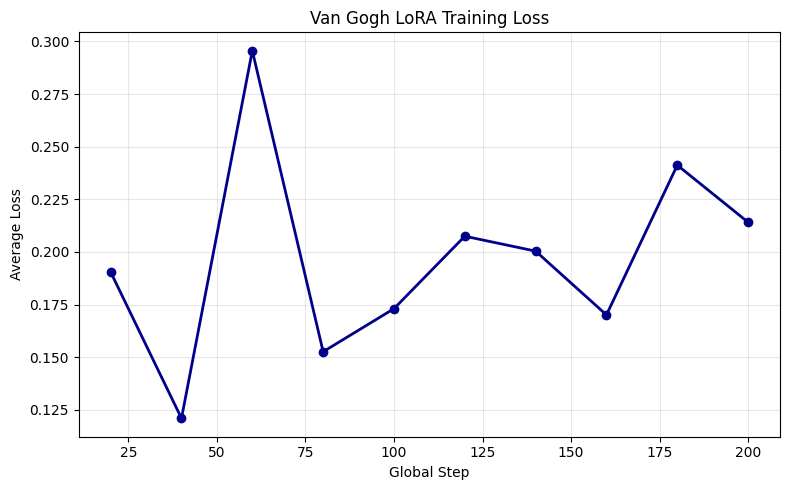

Training Summary
Number of images: 30
Resolution: 512x512
Epochs: 7
Gradient accumulation steps: 4
Total training steps: 210
Learning rate: 5e-05
Final logged loss: 0.2141
Best (lowest) loss: 0.1210
Average logged loss: 0.1966


In [11]:
plt.figure(figsize=(8, 5))
plt.plot(log_steps, loss_history, marker="o", linewidth=2, color="darkblue")
plt.title("Van Gogh LoRA Training Loss")
plt.xlabel("Global Step")
plt.ylabel("Average Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Training Summary")
print(f"Number of images: {len(dataset)}")
print(f"Resolution: 512x512")
print(f"Epochs: {num_epochs}")
print(f"Gradient accumulation steps: {grad_accum_steps}")
print(f"Total training steps: {global_step}")
print(f"Learning rate: {learning_rate}")

if len(loss_history) > 0:
    print(f"Final logged loss: {loss_history[-1]:.4f}")
    print(f"Best (lowest) loss: {min(loss_history):.4f}")
    print(f"Average logged loss: {sum(loss_history)/len(loss_history):.4f}")

In [12]:
from datasets import load_dataset
from diffusers import AutoPipelineForImage2Image
import matplotlib.pyplot as plt

# Load evaluation dataset
test_ds = load_dataset("mertcobanov/nature-dataset", split="train", streaming=True)
num_images = 10

# Load base img2img pipeline and your trained Van Gogh LoRA
test_pipe = AutoPipelineForImage2Image.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

test_pipe.load_lora_weights(output_dir)
test_pipe.fuse_lora()

original_images = []
stylized_images = []
captions = []

for i, test_sample in enumerate(test_ds):
    if i >= num_images:
        break

    init_image = test_sample["image"].convert("RGB").resize((512, 512))
    caption = test_sample["caption"]

    result = test_pipe(
        prompt=f"{caption}, in vgoghstyle, Van Gogh painting, expressive brush strokes, textured oil painting",
        image=init_image,
        strength=0.6,
        guidance_scale=7.5
    ).images[0]

    original_images.append(init_image)
    stylized_images.append(result)
    captions.append(caption)

fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))

for i in range(num_images):
    axes[i, 0].imshow(original_images[i])
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(stylized_images[i])
    axes[i, 1].set_title(f"Van Gogh {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

# Animestyle

I am only downloading first 30 images because I do not have enough GPU on free Colab.

## Loading Dataset that has anime style images and training

In [13]:
from datasets import load_dataset
from PIL import Image
import os

dataset_name = "minoruskore/anime_wallpapers"
num_samples = 30
image_dir = "/content/anime_data/images"
caption_dir = "/content/anime_data/caption"
target_size = 512

os.makedirs(image_dir, exist_ok=True)
os.makedirs(caption_dir, exist_ok=True)

ds = load_dataset(dataset_name, split="train", streaming=True)

saved = 0
for sample in ds:
    if saved >= num_samples:
        break

    img = sample["image"]
    img = resize_and_center_crop(img, size=target_size)

    base_name = f"img{saved+1:03d}"
    img.save(os.path.join(image_dir, f"{base_name}.jpg"), quality=95)

    with open(os.path.join(caption_dir, f"{base_name}.txt"), "w", encoding="utf-8") as f:
        f.write("anime style illustration")

    saved += 1
    # print(f"saved {saved}/{num_samples}")

print(f"Finished. Saved {saved} images.")


Resolving data files:   0%|          | 0/10773 [00:00<?, ?it/s]

Finished. Saved 30 images.


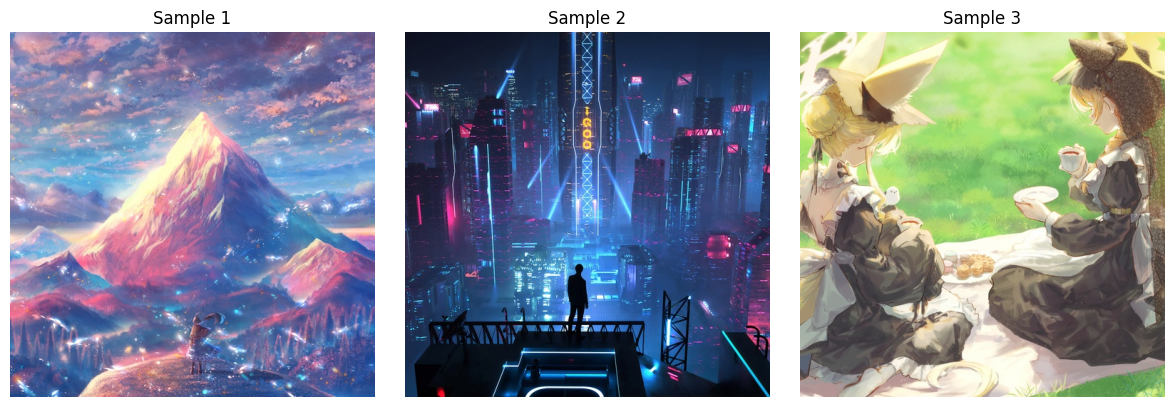

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes, start=1):
    img = Image.open(os.path.join(image_dir, f"img{i:03d}.jpg"))
    ax.imshow(img)
    ax.set_title(f"Sample {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [15]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
vae = pipe.vae
unet = pipe.unet
noise_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [16]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.1,
    bias="none"
)

unet.add_adapter(lora_config)

trainable_count = 0
for name, param in unet.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()
        trainable_count += param.numel()

print("Trainable LoRA params:", trainable_count)


Trainable LoRA params: 1594368


In [17]:
class AnimeDataset(Dataset):
    def __init__(self, image_dir, caption_dir, tokenizer, size=512):
        self.image_dir = image_dir
        self.caption_dir = caption_dir
        self.tokenizer = tokenizer
        self.files = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".jpg") or f.endswith(".png") or f.endswith(".jpeg")
        ])

        self.transform = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        image_name = self.files[idx]
        base = os.path.splitext(image_name)[0]
        caption_path = os.path.join(self.caption_dir, base + ".txt")

        image = Image.open(os.path.join(self.image_dir, image_name)).convert("RGB")
        image = self.transform(image)

        with open(caption_path, "r", encoding="utf-8") as f:
            caption = f.read().strip()

        tokens = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt"
        )

        return {
            "pixel_values": image,
            "input_ids": tokens.input_ids[0]
        }


In [18]:
dataset = AnimeDataset(image_dir, caption_dir, tokenizer, size=resolution)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.AdamW(
    [p for p in unet.parameters() if p.requires_grad],
    lr=learning_rate
)

print("Dataset size:", len(dataset))


Dataset size: 30


In [19]:
import os
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

output_dir = "/content/anime_lora_manual"
os.makedirs(output_dir, exist_ok=True)

unet.train()
global_step = 0
loss_history = []
log_steps = []

optimizer.zero_grad(set_to_none=True)

for epoch in range(num_epochs):
    running_loss = 0.0
    logged_steps = 0
    hit_nan = False

    for step, batch in enumerate(dataloader):
        pixel_values = batch["pixel_values"].to(device, dtype=next(vae.parameters()).dtype)
        input_ids = batch["input_ids"].to(device)

        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

            noise = torch.randn_like(latents)
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],),
                device=device
            ).long()

            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = text_encoder(input_ids)[0]

        model_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_hidden_states
        ).sample

        raw_loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        loss = raw_loss / grad_accum_steps

        if torch.isnan(raw_loss) or torch.isinf(raw_loss):
            print(f"NaN detected at epoch={epoch+1}, batch={step+1}, global_step={global_step}")
            optimizer.zero_grad(set_to_none=True)
            hit_nan = True
            break

        loss.backward()

        if (step + 1) % grad_accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(
                [p for p in unet.parameters() if p.requires_grad],
                max_grad_norm
            )
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        running_loss += raw_loss.item()
        logged_steps += 1
        global_step += 1

        if global_step % 20 == 0:
            avg_loss = running_loss / logged_steps
            print(f"epoch={epoch+1}, step={global_step}, loss={avg_loss:.4f}")
            loss_history.append(avg_loss)
            log_steps.append(global_step)
            running_loss = 0.0
            logged_steps = 0

    if not hit_nan and len(dataloader) % grad_accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(
            [p for p in unet.parameters() if p.requires_grad],
            max_grad_norm
        )
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    if hit_nan:
        print(f"Stopping early because training became unstable in epoch {epoch+1}.")
        break

if logged_steps > 0:
    avg_loss = running_loss / logged_steps
    print(f"final partial log loss={avg_loss:.4f}")
    loss_history.append(avg_loss)
    log_steps.append(global_step)

unet.save_attn_procs(output_dir)
print("Saved to:", output_dir)


epoch=1, step=20, loss=0.2070
epoch=2, step=40, loss=0.2173
epoch=2, step=60, loss=0.1252
epoch=3, step=80, loss=0.1566
epoch=4, step=100, loss=0.2080
epoch=4, step=120, loss=0.1535
epoch=5, step=140, loss=0.1583
epoch=6, step=160, loss=0.1979
epoch=6, step=180, loss=0.0983
epoch=7, step=200, loss=0.1062
final partial log loss=0.1489
Saved to: /content/anime_lora_manual


## Evaluation for AnimeStyle

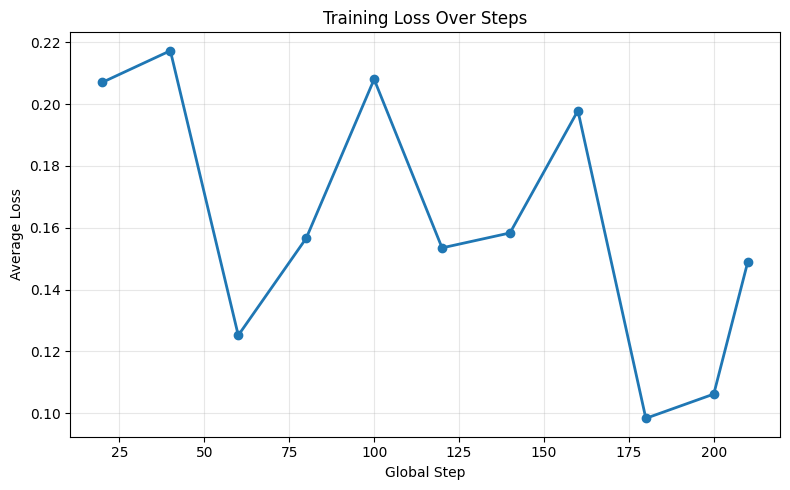

Training Summary
Number of images: 30
Resolution: 512x512
Epochs: 7
Gradient accumulation steps: 4
Total training steps: 210
Learning rate: 5e-05
Final logged loss: 0.1489
Best (lowest) loss: 0.0983
Average logged loss: 0.1616


In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(log_steps, loss_history, marker="o", linewidth=2)
plt.title("Training Loss Over Steps")
plt.xlabel("Global Step")
plt.ylabel("Average Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Training Summary")
print(f"Number of images: {len(dataset)}")
print(f"Resolution: 512x512")
print(f"Epochs: {num_epochs}")
print(f"Gradient accumulation steps: {grad_accum_steps}")
print(f"Total training steps: {global_step}")
print(f"Learning rate: {learning_rate}")

if len(loss_history) > 0:
    print(f"Final logged loss: {loss_history[-1]:.4f}")
    print(f"Best (lowest) loss: {min(loss_history):.4f}")
    print(f"Average logged loss: {sum(loss_history)/len(loss_history):.4f}")

In [21]:
from datasets import load_dataset
from diffusers import AutoPipelineForImage2Image
import matplotlib.pyplot as plt

num_images = 10

test_ds = load_dataset("mertcobanov/nature-dataset", split="train", streaming=True)

anime_pipe = AutoPipelineForImage2Image.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

anime_pipe.load_lora_weights(output_dir)
anime_pipe.fuse_lora()

original_images = []
anime_images = []
captions = []

for i, test_sample in enumerate(test_ds):
    if i >= num_images:
        break

    init_image = test_sample["image"].convert("RGB").resize((512, 512))
    caption = test_sample["caption"]

    result = anime_pipe(
        prompt=f"{caption}, anime style illustration, clean line art, colorful shading",
        image=init_image,
        strength=0.6,
        guidance_scale=7.5
    ).images[0]

    original_images.append(init_image)
    anime_images.append(result)
    captions.append(caption)

fig, axes = plt.subplots(num_images, 2, figsize=(12, 5 * num_images))

for i in range(num_images):
    axes[i, 0].imshow(original_images[i])
    axes[i, 0].set_title(f"Original {i+1}\n{captions[i]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(anime_images[i])
    axes[i, 1].set_title(f"Anime Style {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

Save the model so I do not have to retrain for interactive visual.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
!cp -r /content/vangogh_lora_manual /content/drive/MyDrive/
!cp -r /content/anime_lora_manual /content/drive/MyDrive/